In [1]:
import torch
import shutil
import os
import time
import numpy as np
import matplotlib.pyplot as plt


from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter13_14 import muscl_reconstruction, transmissive_bc, reflective_bc
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter16 import strang_update
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter10 import HLLC_Riemann_Solver
from CFD import Simulator
from CFD import create_explosion_initial_condition

from CFD import U_to_W, W_to_U

from CFD import create_sphere_mask

from CFD import RadiativeTransfer
from CFD import AdvectingField
from CFD import create_random_sphere_points, LinesOnVolume

from JupyterVisualizer import VideoRecorder, visualize_voxel, visualize_point_cloud

from util import create_boundary_band_solid_mask
from util import save_wav_from_pressure_traces


# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

folder1 = "/mnt/storage/lines"
folder2 = "/mnt/storage/pressure"

shutil.rmtree(folder1, ignore_errors=True)
os.makedirs(folder1, exist_ok=True)
shutil.rmtree(folder2, ignore_errors=True)
os.makedirs(folder2, exist_ok=True)


Using device: cuda
CUDA device: NVIDIA GeForce RTX 5080


In [2]:
#PARAMETERS-----------------------------------------------------

#physical quantities--------------------------------------------

X_DOMAIN = [0, 1] # 1 m
Y_DOMAIN = [0, 1] # 1 m
Z_DOMAIN = [0, (1 + 2 ** 0.5) ** 0.5]
T_DOMAIN = [0, 0.08]
EXPLOSION_T = 0.12

GAMMA = 1.4

#simulation parameters--------------------------------------------
#z, y, x
#for 2dim simulateion set z_domain to 1
DIMENSION = 3

RESOLUTION = 50, 100, 100

DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.6
TOL = 1e-6

#explosion parameters--------------------------------------------

# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

# Initial Conditions
rho_inner_phy = 1.225 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.01
boundary_band_radius = 1
center = (-0.70710678, 0.5,  0)

FPS = 45
PB_speed = 0.006

print(f"total video time: {(T_DOMAIN[1] - T_DOMAIN[0]) / PB_speed}")

total video time: 13.333333333333334


In [3]:
nz, ny, nx = RESOLUTION

#initial condition
CELL = torch.zeros((nz, ny, nx, 5), device=device)
CELL[..., 0] = rho_outer
CELL[..., 4] = p_outer

explosion_mask = create_sphere_mask(RESOLUTION,
                                    X_DOMAIN,
                                    Y_DOMAIN,
                                    Z_DOMAIN,
                                    boundary_band_radius,
                                    center = center
                                    )

#시간당 에너지 및 물질 주입량(J/s, kg/s).
source = torch.zeros((nz, ny, nx, 5), device=device)
source[..., 4][explosion_mask] = 25000
source[..., 0][explosion_mask] = 12


In [4]:
boundary_band = create_boundary_band_solid_mask(
    RESOLUTION, 0.07, 0.2, boundary_band_radius, X_DOMAIN, Y_DOMAIN, Z_DOMAIN, band_half_thickness=0.01, center = center
)

solid_cell = boundary_band
solid_cell[:, :, 0] = True
solid_cell[0, :, :] = True

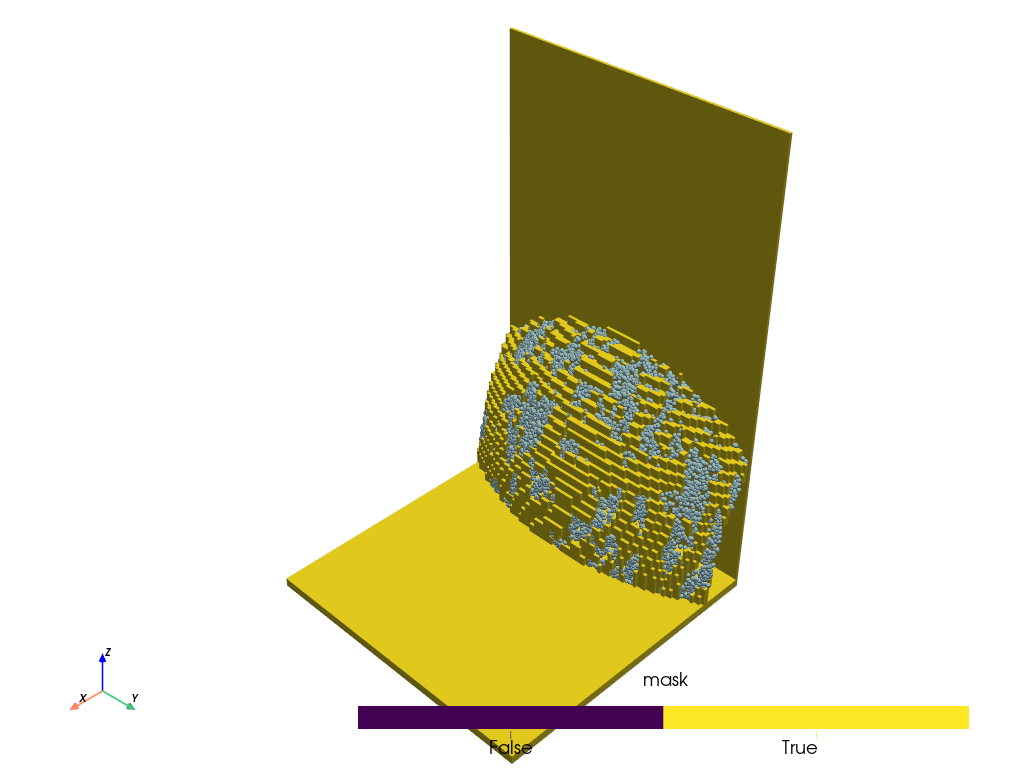

Saved video to solid_cell.mp4


In [5]:
#lines on volume parameters----------------------------------------
num_polylines = 150000
num_points = 200

lines = create_random_sphere_points(
    boundary_band_radius,
    num_polylines,
    num_points,
    X_DOMAIN,
    Y_DOMAIN,
    Z_DOMAIN,
    center = center,
    device=device
)

# lines: (num_polylines, num_points, 4)
# 첫 번째 점의 xyz만 사용
first_points = lines[:, 0, :3]   # (num_polylines, 3)

# domain에서 voxel index로 변환
# 가정:
# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)
x_min, _ = X_DOMAIN
y_min, _ = Y_DOMAIN
z_min, _ = Z_DOMAIN

ix = ((first_points[:, 0] - x_min) / DX).long()
iy = ((first_points[:, 1] - y_min) / DY).long()
iz = ((first_points[:, 2] - z_min) / DZ).long()

# index 범위 보호
ix = torch.clamp(ix, 0, RESOLUTION[2] - 1)
iy = torch.clamp(iy, 0, RESOLUTION[1] - 1)
iz = torch.clamp(iz, 0, RESOLUTION[0] - 1)

# boundary_band 위에 있는 polyline 제거
# boundary_band가 bool tensor든 0/1 tensor든 동작 가능
keep_mask = boundary_band[iz, iy, ix] == 0

lines = lines[keep_mask]


lines = LinesOnVolume(2000, 2000, lines, X_DOMAIN, Y_DOMAIN, Z_DOMAIN)

point_cloud = lines.lines[:, 0, :3].clone()

point_cloud[:, 0] = (point_cloud[:, 0] - X_DOMAIN[0])
point_cloud[:, 1] = (point_cloud[:, 1] - Y_DOMAIN[0])
point_cloud[:, 2] = (point_cloud[:, 2] - Z_DOMAIN[0])

#visualize_point_cloud(point_cloud, save_path = "./point_cloud.mp4")
visualize_voxel(solid_cell, spacing = (DX, DY, DZ), point_cloud = point_cloud, save_path = 'solid_cell.mp4')

In [6]:
print(point_cloud.shape)

torch.Size([3072, 3])


In [7]:
# Soot visualization

mask1 = create_sphere_mask(RESOLUTION,
                                    X_DOMAIN,
                                    Y_DOMAIN,
                                    Z_DOMAIN,
                                    boundary_band_radius + 0.1,
                                    center=center
                                    )

mask2 = create_sphere_mask(RESOLUTION,
                                    X_DOMAIN,
                                    Y_DOMAIN,
                                    Z_DOMAIN,
                                    boundary_band_radius,
                                    center=center
                                    )

soot_mask = mask1 & (~mask2)

#Radiative transfer visualization

RT = RadiativeTransfer(
    RESOLUTION,
    k_a = 2.0, 
    k_s = 4.0, 
    R_star = 1 / 290, 
    T_ref = 3000, 
    soot_mask = soot_mask,
    device=device
)

In [8]:
sim = Simulator(
    CELL,
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=HLLC_Riemann_Solver,
    reconstruction_method=muscl_reconstruction,
    boundary_function=transmissive_bc,
    update_method=strang_update,
    solid_cell = solid_cell,
    dimension=DIMENSION,
    visualizers=[RT, lines]
)

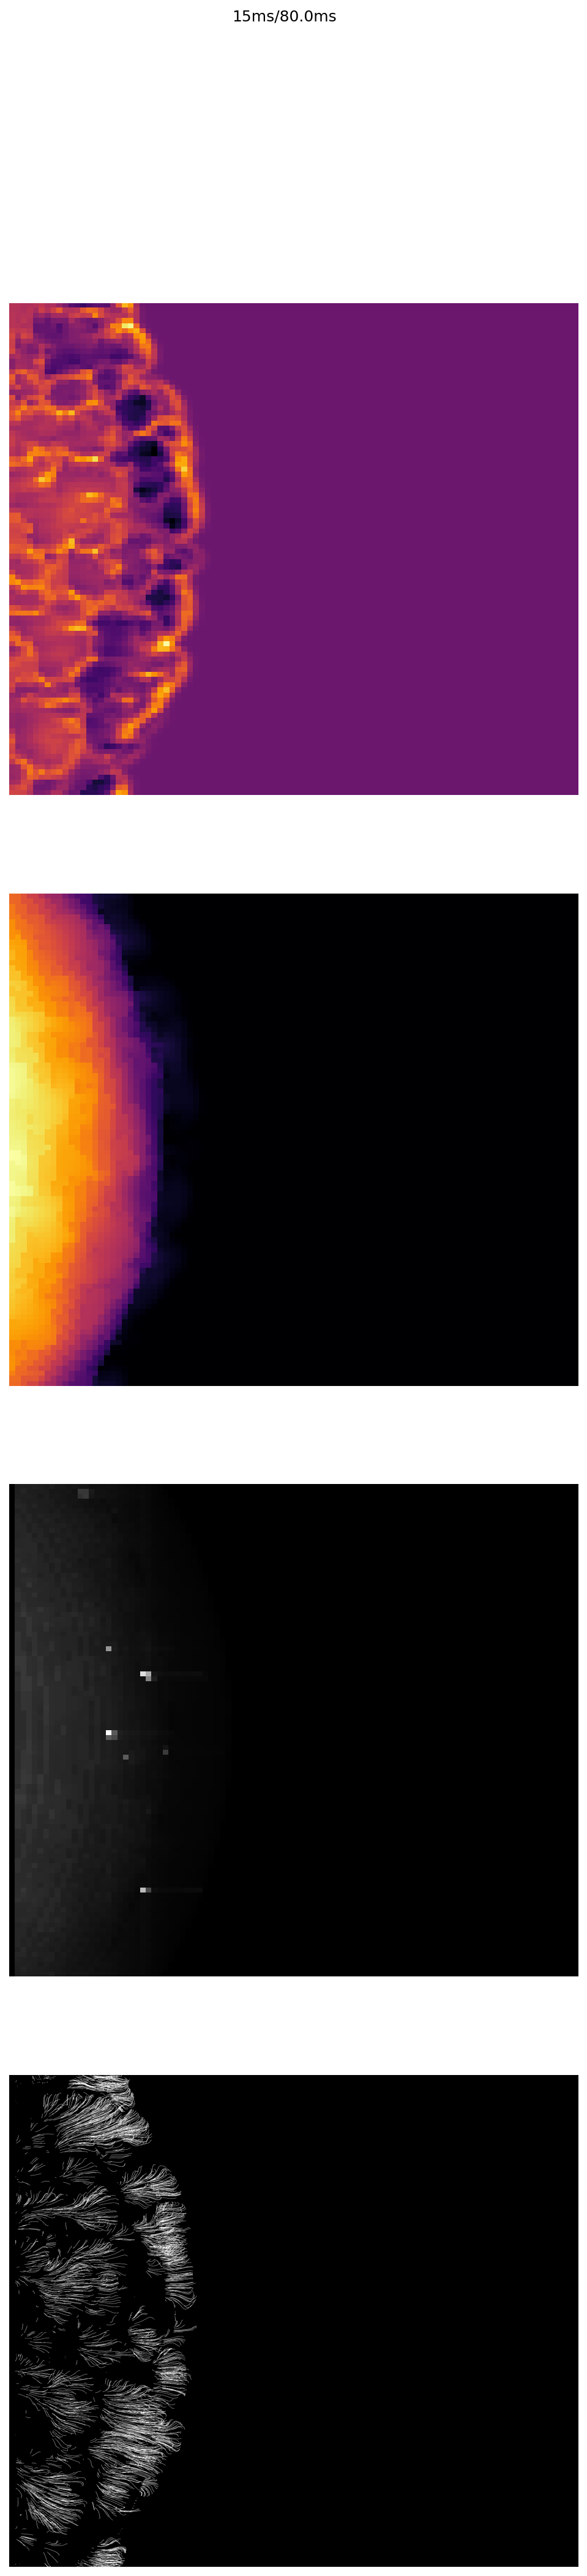

In [ ]:
t = T_DOMAIN[0]
# set it to -1 to make it immediately record after simulation starts.
recorded_t = -1


y_center = int(RESOLUTION[1] / 2)
x_center = int(RESOLUTION[2] / 2)
z_pos = int(RESOLUTION[0] / 2)

near = int(0.1 / DX)
far = 2 * near

IV = VideoRecorder((sim.get_images_num(), 1), record = True, save_path="./explosion_simulation", figsize=(8, 8 * sim.get_images_num()), cmaps = ['inferno', 'inferno', 'gray'])

while t < T_DOMAIN[1]:
    dt = sim.update()
    t += dt
    μs = int(t * 1000000)

    torch.save(sim.cell[..., 4].cpu(), os.path.join(folder2, f"{μs:09d}.pt") )
    
    if(t < EXPLOSION_T):
        U = W_to_U(sim.cell, GAMMA)
        U += dt * source
        sim.cell = U_to_W(U, GAMMA)

    #2ms 이상 지나면 기록
    if(t - recorded_t > (1 / FPS) * PB_speed):
        torch.save(lines.lines.cpu(), os.path.join(folder1, f"{μs:09d}.pt"))
        IV.set_title(f"{round(t * 1000)}ms/{T_DOMAIN[1] * 1000}ms")
        images = sim.get_images()

        IV.update(images, t)
        recorded_t = t
        #torch.save(sim.cell, os.path.join(folder, f"{μs:09d}.pt") )

In [ ]:
IV.close(PB_speed=PB_speed)

In [ ]:
params = {
    # domain
    "X_DOMAIN": X_DOMAIN,
    "Y_DOMAIN": Y_DOMAIN,
    "Z_DOMAIN": Z_DOMAIN,
    "T_DOMAIN": T_DOMAIN,
    "EXPLOSION_T": EXPLOSION_T,

    # simulation
    "DIMENSION": DIMENSION,
    "RESOLUTION": RESOLUTION,
    "DX": DX,
    "DY": DY,
    "DZ": DZ,
    "CFL_COEFFICIENT": CFL_COEFFICIENT,
    "TOL": TOL,

    # physics
    "GAMMA": GAMMA,
    "rho0": rho0,
    "p0": p0,
    "u0": u0,

    # explosion
    "rho_inner_phy": rho_inner_phy,
    "p_inner_phy": p_inner_phy,
    "rho_outer_phy": rho_outer_phy,
    "p_outer_phy": p_outer_phy,

    "rho_inner": rho_inner,
    "p_inner": p_inner,
    "rho_outer": rho_outer,
    "p_outer": p_outer,

    "sigma": sigma,
    "boundary_band_radius": boundary_band_radius,
}

torch.save(params, "/mnt/storage/params.pt")